# **Caso de estudio: Dogs vs Cats**

In [1]:
import os

In [2]:
base_dir = './cats_and_dogs_small'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Directorios con las imágnes de training
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Directorios con las imágnes de validation
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

# Directorios con las imágnes de test
test_cats_dir = os.path.join(test_dir, 'cats')
test_dogs_dir = os.path.join(test_dir, 'dogs')

### Comprobar contenido de los directorios

In [3]:
train_cats_fnames = os.listdir(train_cats_dir)
print(train_cats_fnames[:5])

train_dogs_fnames = os.listdir(train_dogs_dir)
print(train_dogs_fnames[:5])

validation_cats_fnames = os.listdir(validation_cats_dir)
print(validation_cats_fnames[:5])

validation_dogs_fnames = os.listdir(validation_dogs_dir)
print(validation_dogs_fnames[:5])

test_cats_fnames = os.listdir(test_cats_dir)
print(test_cats_fnames[:5])

test_dogs_fnames = os.listdir(test_dogs_dir)
print(test_dogs_fnames[:5])

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.101.jpg']
['dog.0.jpg', 'dog.1.jpg', 'dog.10.jpg', 'dog.100.jpg', 'dog.101.jpg']
['cat.1000.jpg', 'cat.1001.jpg', 'cat.1002.jpg', 'cat.1003.jpg', 'cat.1004.jpg']
['dog.1000.jpg', 'dog.1001.jpg', 'dog.1002.jpg', 'dog.1003.jpg', 'dog.1004.jpg']
['cat.1500.jpg', 'cat.1501.jpg', 'cat.1502.jpg', 'cat.1503.jpg', 'cat.1504.jpg']
['dog.1500.jpg', 'dog.1501.jpg', 'dog.1502.jpg', 'dog.1503.jpg', 'dog.1504.jpg']


### Comprobar el número de imágenes

In [4]:
print(f'total training cat images: {len(train_cats_fnames)}')
print(f'total training dog images: {len(train_dogs_fnames)}')
print(f'total validation cat images: {len(validation_cats_fnames)}')
print(f'total validation dog images: {len(validation_dogs_fnames)}')
print(f'total test cat images: {len(test_cats_fnames)}')
print(f'total test dog images: {len(test_dogs_fnames)}')

total training cat images: 1000
total training dog images: 1000
total validation cat images: 500
total validation dog images: 500
total test cat images: 500
total test dog images: 500


### Comprobación visual

In [5]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def print_pictures(dir, fnames):
    nrows = 4
    ncols = 4
    
    pic_index = 0
    
    fig = plt.gcf()
    fig.set_size_inches(ncols * 4, nrows * 4)
    
    pic_index += 8
    
    next_cat_pix = [os.path.join(dir, fnames[i]) 
                        for i in range(pic_index-8, pic_index)
                    ]
    
    for i, img_path in enumerate(next_cat_pix):
        sp = plt.subplot(nrows, ncols, i + 1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
    
    plt.show()

Figura 10.3


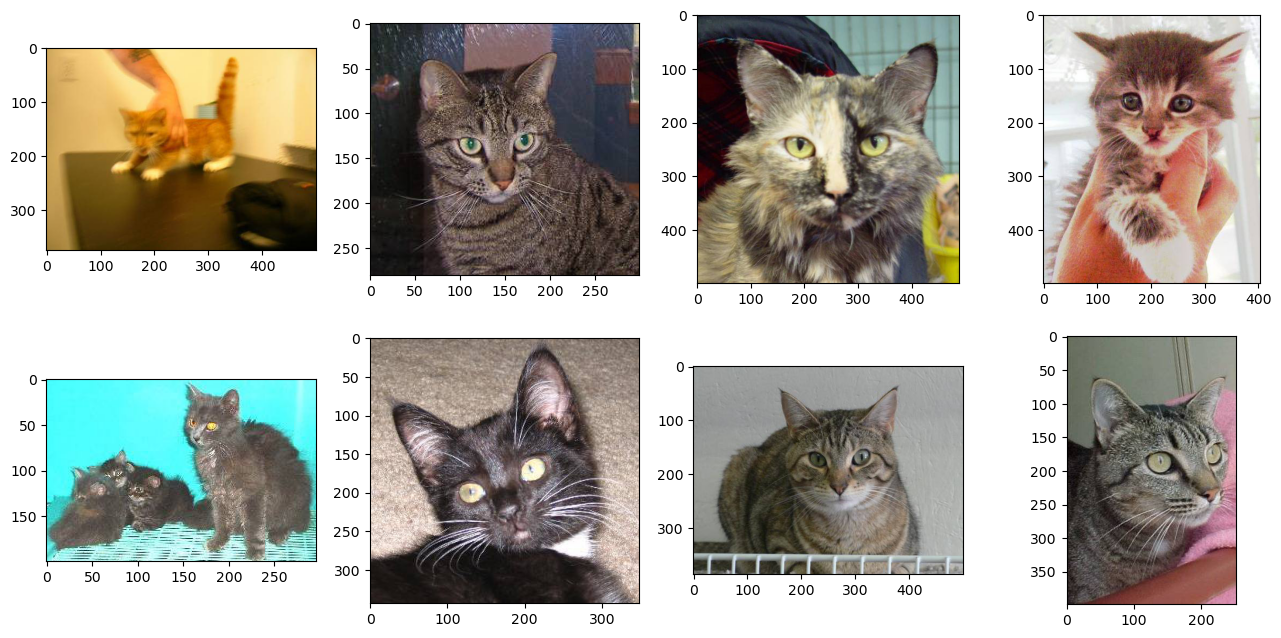

Figura 10.4


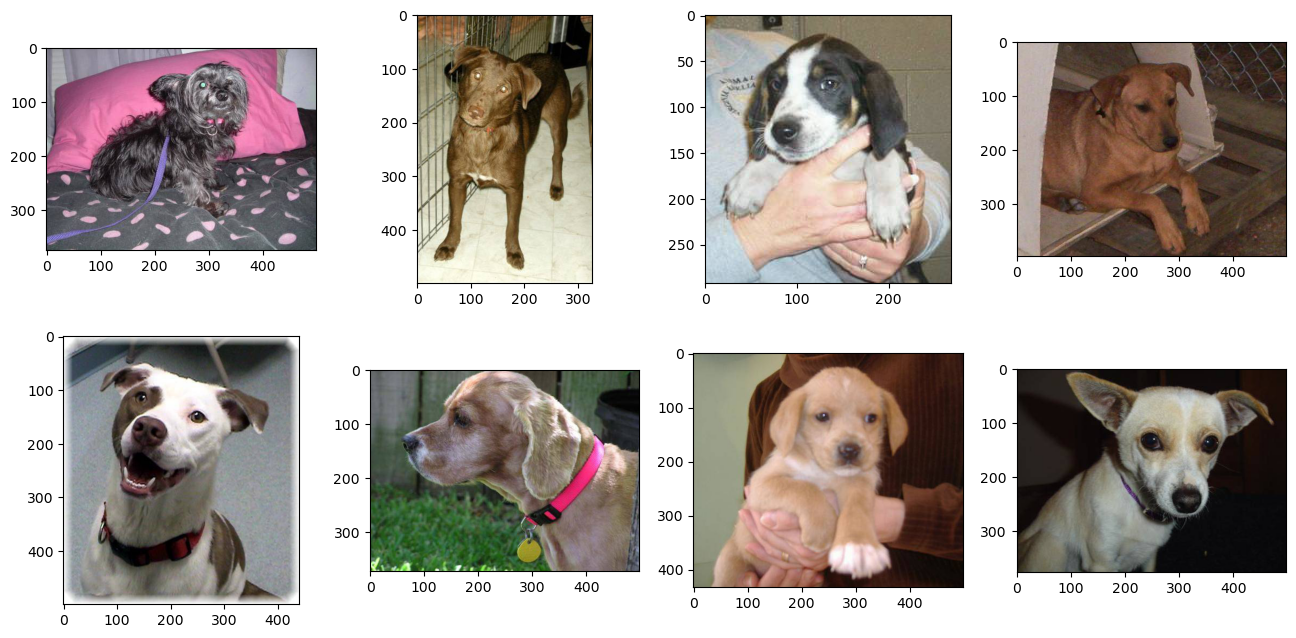

Figura 10.5


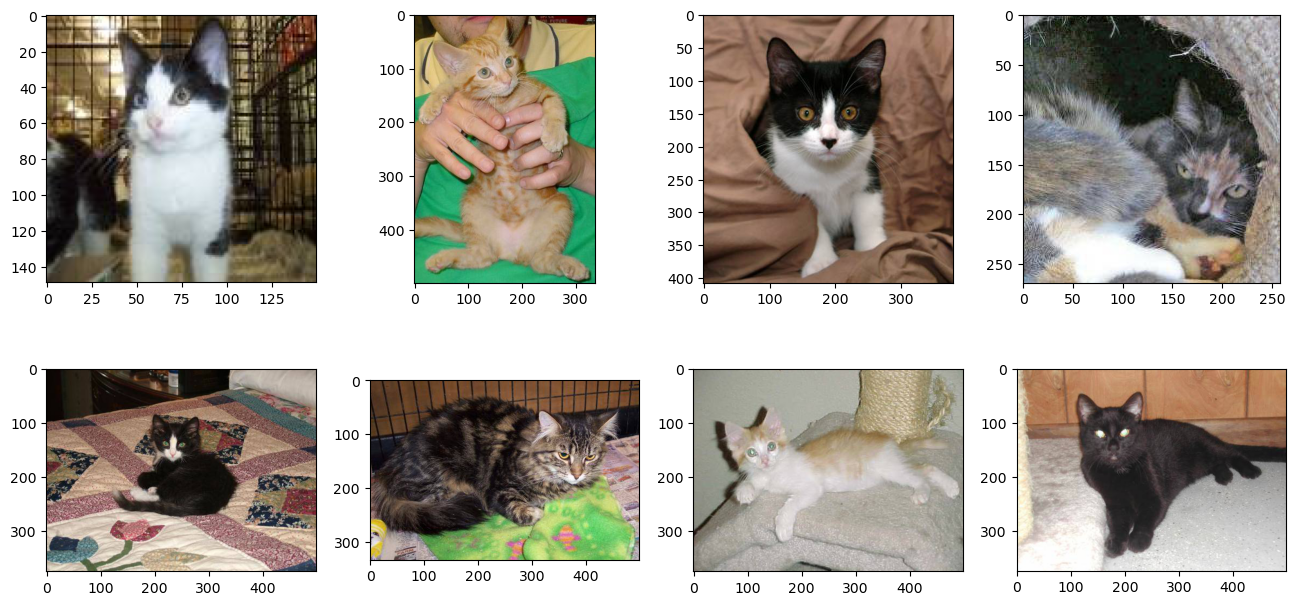

Figura 10.6


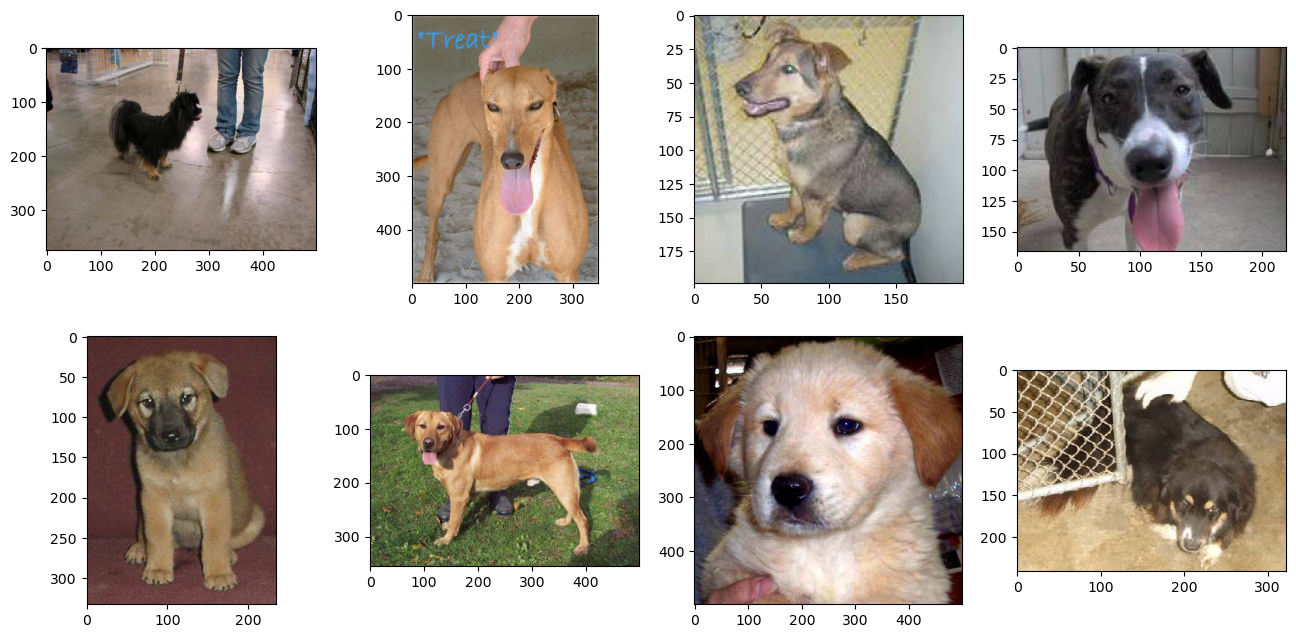

Figura 10.7


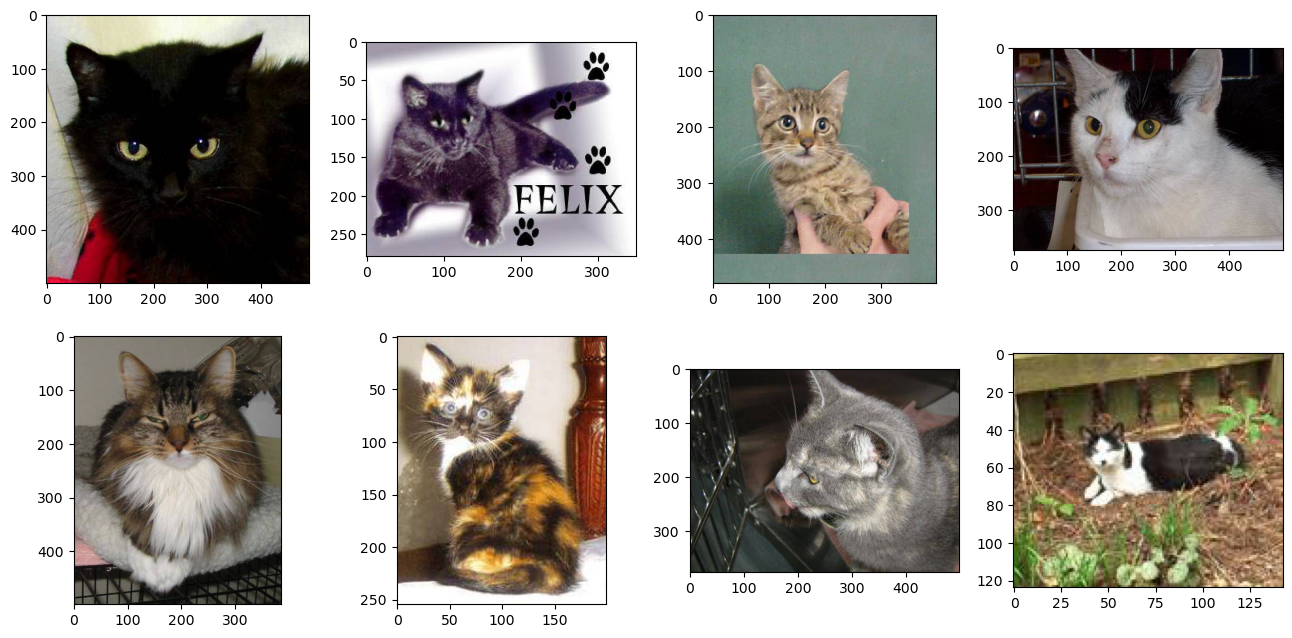

Figura 10.8


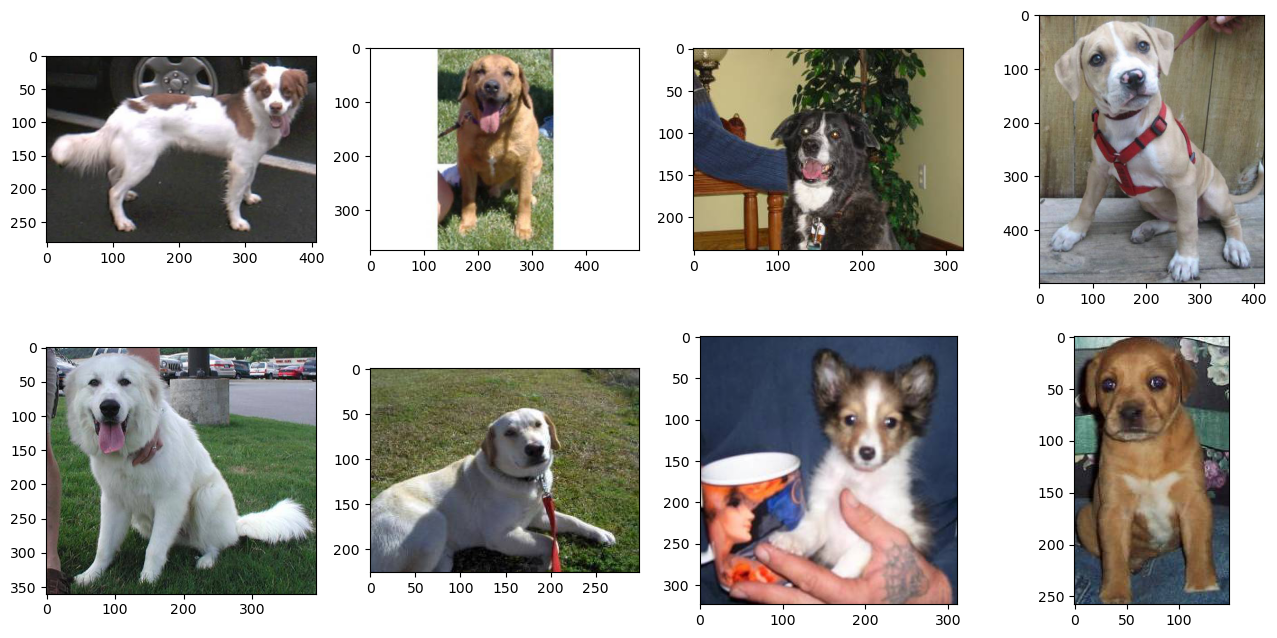

In [6]:
print("Figura 10.3")
print_pictures(train_cats_dir, train_cats_fnames)
print("Figura 10.4")
print_pictures(train_dogs_dir, train_dogs_fnames)
print("Figura 10.5")
print_pictures(validation_cats_dir, validation_cats_fnames)
print("Figura 10.6")
print_pictures(validation_dogs_dir, validation_dogs_fnames)
print("Figura 10.7")
print_pictures(test_cats_dir, test_cats_fnames)
print("Figura 10.8")
print_pictures(test_dogs_dir, test_dogs_fnames)

### Modelo

In [7]:
import tensorflow as tf
from tensorflow.keras import Model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', 
                 input_shape=(150, 150, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\angel\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

### Optimizador

In [9]:
from tensorflow.keras.optimizers import RMSprop

model.compile(optimizer=RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

### Preprocesado de datos reales con ImageDataGenerator

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1.0/255)
validation_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

In [11]:
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=20,
                                                    class_mode='binary',
                                                    target_size=(150, 150))

validation_generator = validation_datagen.flow_from_directory(validation_dir,
                                                    batch_size=20,
                                                    class_mode='binary',
                                                    target_size=(150, 150))

test_generator = test_datagen.flow_from_directory(test_dir,
                                                    batch_size=20,
                                                    class_mode='binary',
                                                    target_size=(150, 150))

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


### Modelos a partir de conjuntos de datos pequeños

In [12]:
batch_size = 20
steps_per_epoch = train_generator.n // batch_size
validation_steps = validation_generator.n // batch_size

print(steps_per_epoch)
print(validation_steps)

100
50


In [13]:
history = model.fit(
        train_generator,
        steps_per_epoch = steps_per_epoch,
        epochs=100,
        validation_data = validation_generator,
        validation_steps = validation_steps,
        verbose=2)

Epoch 1/100
100/100 - 17s - 167ms/step - accuracy: 0.5190 - loss: 0.6937 - val_accuracy: 0.5720 - val_loss: 0.6842
Epoch 2/100
100/100 - 13s - 129ms/step - accuracy: 0.5740 - loss: 0.6737 - val_accuracy: 0.6220 - val_loss: 0.6605
Epoch 3/100
100/100 - 13s - 131ms/step - accuracy: 0.6170 - loss: 0.6487 - val_accuracy: 0.6290 - val_loss: 0.6442
Epoch 4/100
100/100 - 16s - 155ms/step - accuracy: 0.6685 - loss: 0.6139 - val_accuracy: 0.5920 - val_loss: 0.6581
Epoch 5/100
100/100 - 16s - 160ms/step - accuracy: 0.6965 - loss: 0.5784 - val_accuracy: 0.6640 - val_loss: 0.6096
Epoch 6/100
100/100 - 17s - 167ms/step - accuracy: 0.7280 - loss: 0.5454 - val_accuracy: 0.5900 - val_loss: 0.7267
Epoch 7/100
100/100 - 17s - 169ms/step - accuracy: 0.7340 - loss: 0.5225 - val_accuracy: 0.6020 - val_loss: 0.7481
Epoch 8/100
100/100 - 17s - 170ms/step - accuracy: 0.7435 - loss: 0.5089 - val_accuracy: 0.6840 - val_loss: 0.5922
Epoch 9/100
100/100 - 19s - 187ms/step - accuracy: 0.7665 - loss: 0.4805 - val_a

In [14]:
history_dict = history.history
print(history_dict.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


C:\Users\angel\AppData\Local\Temp\ipykernel_10180\2817839205.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 640x480 with 0 Axes>

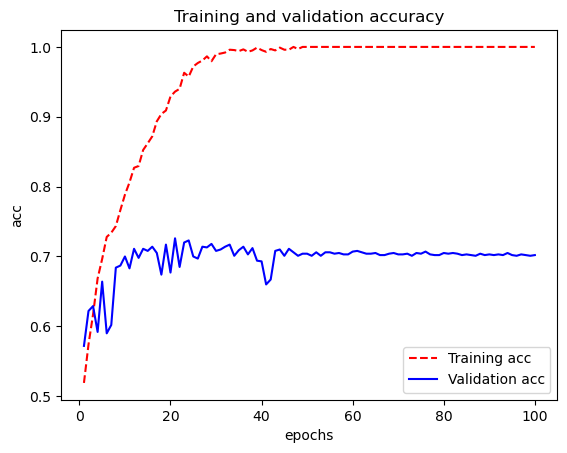

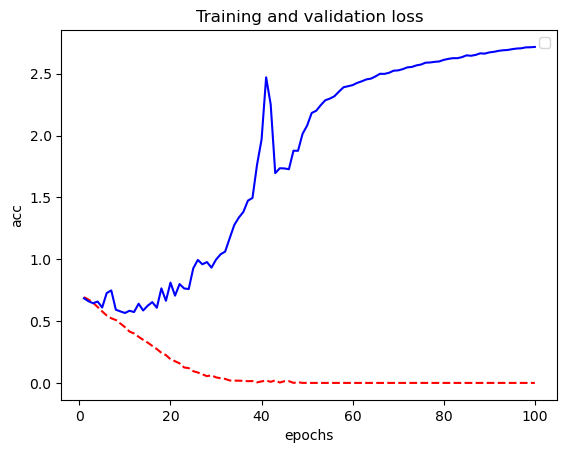

<Figure size 640x480 with 0 Axes>

In [15]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(acc) + 1, 1)

plt.plot(epochs, acc, 'r--', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.ylabel('acc')
plt.xlabel('epochs')

plt.legend()
plt.figure()
plt.plot(epochs, loss, 'r--')
plt.plot(epochs, val_loss, 'b')
plt.title('Training and validation loss')
plt.ylabel('acc')
plt.xlabel('epochs')

plt.legend()
plt.figure()

In [16]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.7070 - loss: 2.5805
Test accuracy: 0.7070


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
[[1.]]


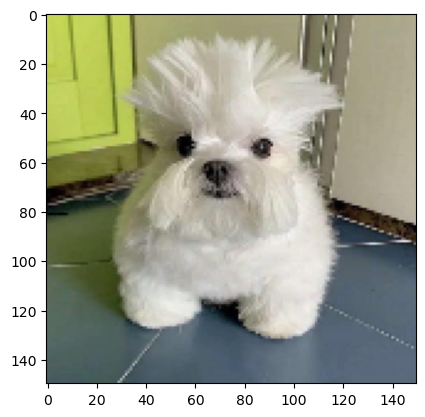

perro.jpg IS A DOG


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

path = "perro.jpg"

img = image.load_img(path, target_size=(150, 150))

x = image.img_to_array(img)

image = np.expand_dims(x, axis=0)

classes = model.predict(image)

print(classes)

plt.imshow(img)
plt.show()

if classes > 0:
    print(path + " IS A DOG")
else:
    print(path + " IS A CAT")

### Cambio en el código

>**Se hizo una pequeña modificación**
<br><br>
```
model.compile(optimizer=RMSprop(lr=1e-4),
loss='binary_crossentropy',
metrics=['accuracy'])
```
a

```
model.compile(optimizer=RMSprop(learning_rate=1e-4),
loss='binary_crossentropy',
metrics=['accuracy'])
```

Debido a que la versión de la API de Keras/Tensorflow es más reciente y ya no acepta lr como argumento, ahora es learning_rate.<br><br>

>**En el código original, debido a que está pensado para usarse en Google Colab se usa lo siguiente:**

```
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
fn = list(uploaded.keys())[0]
path = '/content/' + fn
```

Se paso a:

```
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

path = "perro.jpg"

img = image.load_img(path, target_size=(150, 150))
```

### **Análisis de resultados**

El modelo aprende muy bien los datos con los que fue entrenado, ya que su precisión llega casi a 1 y el error se vuelve muy pequeño. Sin embargo, cuando se evalúa con datos de validación, la precisión se queda aproximadamente en 0.70 y el error empieza a aumentar con el paso de las épocas. Esto indica que el modelo se ajusta demasiado a los datos de entrenamiento y no generaliza tan bien con datos nuevos.

Cuando probé el modelo con una imagen de un perro, la clasificación fue correcta, lo que significa que sí aprendió algunas características para identificar este tipo de imágenes. Sin embargo, este comportamiento se relaciona con lo que en el libro se menciona como overfitting, que ocurre cuando el modelo aprende demasiado los datos de entrenamiento en lugar de aprender patrones más generales.
